In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error
)

In [3]:
data = 'Dataset/fish.csv'
df = pd.read_csv(data)

df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.shape

(159, 7)

In [6]:
df = pd.get_dummies(df, columns=['Species'], drop_first=True)

In [7]:
X = df.drop("Weight", axis=1)
y = df["Weight"]

In [8]:
x1, x2, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [10]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(x1)
X_test_poly = poly.transform(x2)

In [11]:
model = LinearRegression()

model.fit(X_train_poly, y_train)

# Prediction
y_pred = model.predict(X_test_poly)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
maxerr = max_error(y_test, y_pred)

In [13]:
# Adjusted R²
n = X_test_poly.shape[0]
p = X_test_poly.shape[1] - 1

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("\n========== Evaluation Metrics ==========")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)
print("Adjusted R2 :", adj_r2)
print("MAPE :", mape)
print("Explained Variance :", evs)
print("Maximum Error :", maxerr)


========== Evaluation Metrics ==========
MAE : 53.619221496582036
MSE : 6847.62217520695
RMSE : 82.750360574483
R2 Score : 0.9518584328737167
Adjusted R2 : 1.0324432300198865
MAPE : 0.25862390306883204
Explained Variance : 0.9545323484665024
Maximum Error : 290.5704345703125


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


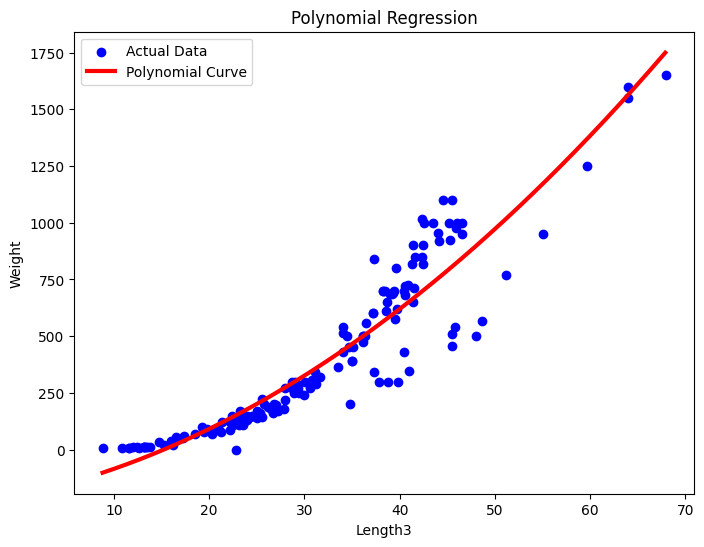

In [14]:
X = df[['Length3']]
y = df['Weight']
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

X_grid = np.arange(
    X.min().values[0],
    X.max().values[0],
    0.1
).reshape(-1,1)

plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue", label="Actual Data")

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color="red",
    linewidth=3,
    label="Polynomial Curve"
)

plt.xlabel("Length3")
plt.ylabel("Weight")
plt.title("Polynomial Regression")
plt.legend()
plt.show()